# 03 — Where the Ground Shakes

**Why do earthquakes and volcanoes happen in the same places, over and over?**

Earthquakes and volcanoes aren't scattered randomly around the world — most
of them happen in narrow bands that trace out the edges of Earth's plates.
The background map already has the real plate boundaries drawn on it (see
Notebook 1 for what the colours mean — red = spreading ridge, orange =
transform, thick dark-blue line = subduction zone). In this notebook you'll
plot real earthquake locations on top and see the pattern for yourself —
including a version of the map that draws the two boundary types that
matter most for earthquakes crisply on top of the dots, so neither one
gets hidden underneath them.

*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*


## Before you start

Run the cell below first.

In [1]:
# Housekeeping — checks the data files this notebook needs are present.
# If this is the first time anyone has opened Deep Time Explorers, a grown-up
# needs to run export_data.py once (see the suite README) before this will work.
from pathlib import Path
import os as _os

if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

_required = [
    "data/basemap_0Ma.png",
    "data/basemap_subduction_0Ma.png",
    "data/notable_earthquakes.csv",
    "data/subduction_zones_0Ma.csv",
    "data/ridges_0Ma.csv",
]
_missing = [f for f in _required if not Path(f).exists()]
if _missing:
    raise FileNotFoundError(
        "Missing data file(s): " + ", ".join(_missing) +
        "\n\nAsk a grown-up to run export_data.py once from the "
        "deep-time-explorers folder — see README.md. "
    )
print("All data files found — ready to go!")


All data files found — ready to go!


In [2]:
# The only packages this notebook needs — all standard, nothing to install
# beyond a normal Jupyter setup.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown


In [3]:
# --- Robinson world-map helpers -------------------------------------------
# These four numbers describe the exact shape of a full-globe "Robinson"
# map projection (the curved world-map style used below). They're always
# the same no matter what age we're looking at, so we only need to write
# them once. export_data.py used the exact same numbers when it made the
# background pictures, so everything lines up perfectly.
ROBINSON_EXTENT = (-20464646.889276125, 17966614.874622703, -10991340.864475066, 10145853.105669294)

def show_basemap(ax, age_ma):
    """Draw the real paleo-elevation world map for a given age. Green/tan
    shows low land, browns and white show mountains — the SAME kind of
    colouring you'd see on a real physical-geography map today."""
    img = plt.imread(f"data/basemap_{int(age_ma)}Ma.png")
    ax.imshow(img, extent=ROBINSON_EXTENT, origin="upper")
    ax.set_xlim(ROBINSON_EXTENT[0], ROBINSON_EXTENT[1])
    ax.set_ylim(ROBINSON_EXTENT[2], ROBINSON_EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([])
    ax.axis("off")


In [4]:
quakes = pd.read_csv("data/notable_earthquakes.csv")
print(f"{len(quakes)} earthquakes loaded")
quakes.head()


246 earthquakes loaded


,lat,lon,mag,place,year,robinson_x,robinson_y
0,-8.3101,121.3517,7.7,"68 km NNW of Ende, Indonesia",2026,1.142689e+07,-8.887811e+05
1,10.6054,-67.2167,7.5,"20 km W of Catia La Mar, Venezuela",2026,-6.317910e+06,1.134268e+06
2,5.5994,125.0560,7.8,"25 km SW of Kablalan, Philippines",2026,1.179483e+07,5.988666e+05
3,-18.5387,-175.4763,7.5,"158 km W of Neiafu, Tonga",2026,-1.632357e+07,-1.982747e+06
4,40.9984,142.1836,7.6,"2025 Aomori Prefecture, Japan Earthquake",2025,1.231584e+07,4.382351e+06


### What makes an earthquake "notable" here?

Earthquakes happen somewhere on Earth almost every day — most far too small
to feel. The dots on the maps below are only the *big* ones: **magnitude
7.5 or higher, going back to 1970** — real events recorded by scientists
(the US Geological Survey), not made-up data. That's why there are only a
couple of hundred dots, not thousands.

(Magnitude is the scale scientists use for how strong an earthquake is.
It jumps fast: each whole number up is about 32 times more energy, so a
magnitude 8 earthquake releases roughly 32× what a magnitude 7 does.)

## Step 1 — just the plate boundaries

Here's today's world. The lines already on the map are real plate
boundaries — no earthquakes plotted yet.

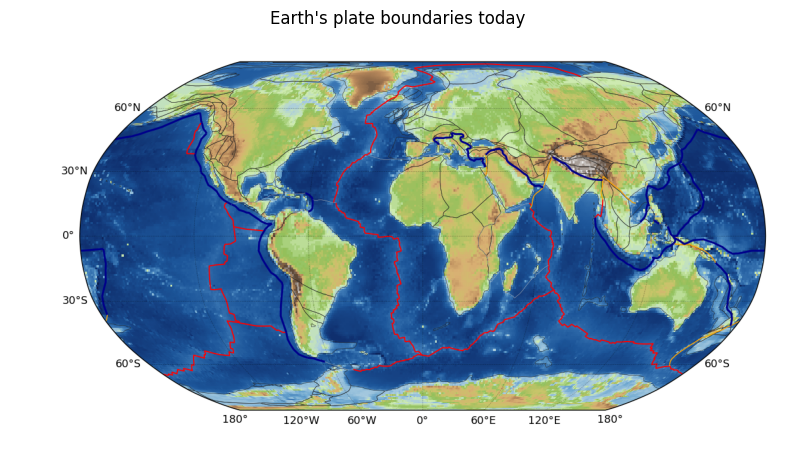

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.7))
show_basemap(ax, 0)
ax.set_title("Earth's plate boundaries today");


## Step 2 — now add the earthquakes

Each white dot below is a real, notable earthquake. Bigger dots mean a
bigger earthquake (measured on the **magnitude** scale — every whole number
up is about 30 times more powerful!).

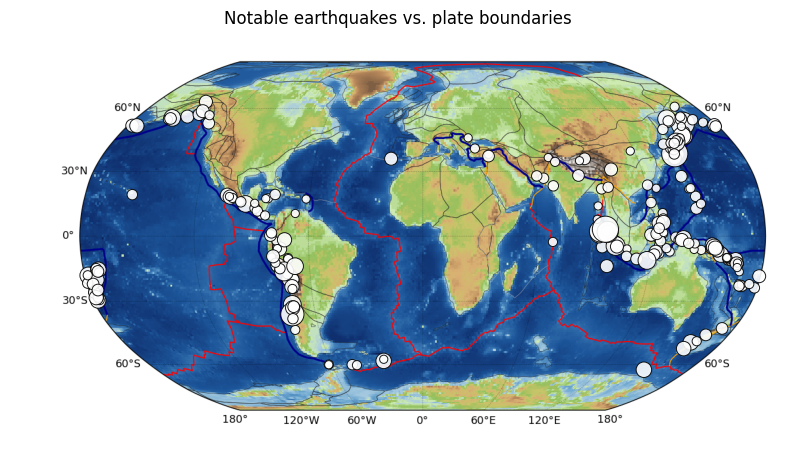

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.7))
show_basemap(ax, 0)
# This dataset is every M7.5+ quake since 1970, so the magnitudes are all
# fairly close together (7.5 to a little over 9) -- scaling marker AREA
# directly off that narrow a range makes every dot only a pixel or two
# across, which is why they used to be invisible. Normalising to 0-1 first,
# then giving every dot a decently large minimum size, keeps the smallest
# quakes clearly visible as dots while still making the biggest ones (like
# Tohoku 2011 or Sumatra 2004) stand out as dramatically larger.
mag_range = quakes["mag"].max() - quakes["mag"].min()
mag_norm = (quakes["mag"] - quakes["mag"].min()) / mag_range
sizes = 35 + mag_norm ** 1.3 * 320
ax.scatter(quakes["robinson_x"], quakes["robinson_y"], s=sizes, color="white",
           alpha=0.9, edgecolor="black", linewidth=0.7, zorder=6)
ax.set_title("Notable earthquakes vs. plate boundaries");


## Step 3 — earthquakes vs. ridges and subduction zones

Step 2's map has *all three* kinds of boundary on it at once. Ridges and
subduction zones are the two that matter most for earthquakes, so here's
the same earthquake dots one more time, with just those two drawn clearly
**on top of the dots** — a red line for ridges (where plates pull apart)
and a thick dark-blue line for subduction zones (where one plate dives
under another). Draw the lines first and the dots would just bury them
again, which is exactly what happened in an earlier version of this
notebook.

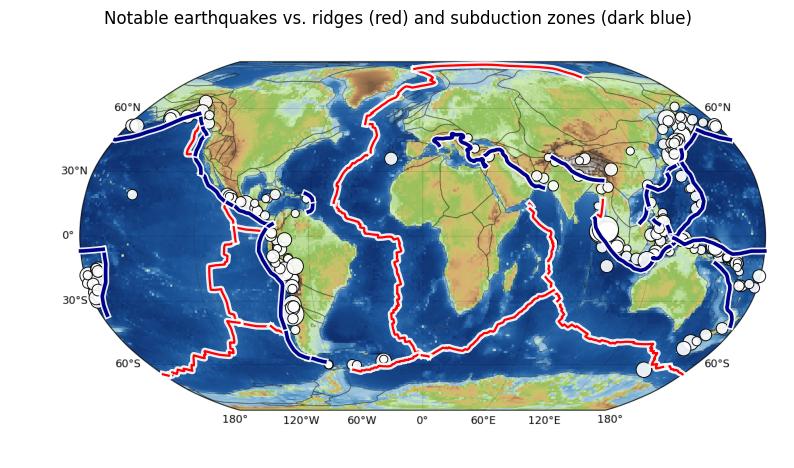

In [7]:
import matplotlib.patheffects as pe

ridges = pd.read_csv("data/ridges_0Ma.csv")
subduction = pd.read_csv("data/subduction_zones_0Ma.csv")

fig, ax = plt.subplots(figsize=(10, 5.7))
img = plt.imread("data/basemap_subduction_0Ma.png")
ax.imshow(img, extent=ROBINSON_EXTENT, origin="upper")
ax.set_xlim(ROBINSON_EXTENT[0], ROBINSON_EXTENT[1])
ax.set_ylim(ROBINSON_EXTENT[2], ROBINSON_EXTENT[3])
ax.set_xticks([]); ax.set_yticks([]); ax.axis("off")
ax.scatter(quakes["robinson_x"], quakes["robinson_y"], s=sizes, color="white",
           alpha=0.9, edgecolor="black", linewidth=0.7, zorder=6)
# Ridges and subduction zones are each a set of SEPARATE lines (grouped by
# `segment_id`) -- plotting them all as one single line per group would
# draw stray straight connectors jumping between unrelated boundaries.
# zorder=10 is higher than the earthquake dots' zorder=6 above -- drawn
# LAST and ON TOP, neither line can be buried by a dot sitting right on
# top of it, which is most of them, since that's exactly where this kind
# of earthquake happens.
# Both lines get a pale halo (path_effects) behind them -- a dark-blue
# line drawn straight onto a dark-blue ocean is nearly invisible without
# one; the halo lifts it off the background without changing the colour
# kids were taught in Notebook 1 (dark blue = subduction zone).
halo = [pe.withStroke(linewidth=5, foreground="white", alpha=0.9)]
for _, seg in ridges.groupby("segment_id"):
    ax.plot(seg["robinson_x"], seg["robinson_y"], color="red", linewidth=1.6,
             zorder=10, path_effects=halo)
for _, seg in subduction.groupby("segment_id"):
    ax.plot(seg["robinson_x"], seg["robinson_y"], color="darkblue", linewidth=2.6,
             zorder=10, path_effects=halo)
ax.set_title("Notable earthquakes vs. ridges (red) and subduction zones (dark blue)");


## What do you notice?

Look at where the dots cluster. Do they scatter evenly across the
continents and oceans, or do they hug the coloured lines? Are there more
dots — and bigger ones — near the dark-blue subduction lines, or the red
ridge lines?

This is one of the strongest pieces of evidence for plate tectonics:
earthquakes and volcanoes happen where plates push into each other, pull
apart, or grind past one another — not randomly. Subduction zones (where
one plate dives beneath another) produce the biggest and deepest
earthquakes of all, which is exactly why the "Ring of Fire" around the
Pacific is both a subduction-zone map AND an earthquake map.

## Try this next!

- Colour the dots by magnitude instead of size (try `c=quakes["mag"], cmap="Reds"`).
- Zoom in on the "Ring of Fire" around the Pacific Ocean — how many quakes can you count hugging the dark-blue subduction line, compared to the red ridge line?
- Find the entry for the biggest earthquake in the table (`quakes.sort_values("mag", ascending=False)`) — where was it, and what year?

---
*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*
